In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# General Process of breaking nth Order to Multiple First order systems
How do you break a higher-order ODE into first-order parts?
The general approach is:

Introduce new variables for each derivative up to one less than the highest order.

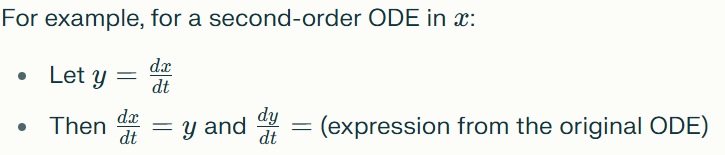

In [2]:
# x is the position,
# y (or dx) is the velocity,
# μ (mew) controls nonlinearity and damping.

# d²x/dt² - μ(1 - x²)dx/dt + x = 0 is the og equation

# As a system of first-order ODEs:
# dx/dt = y
# dy/dt = μ(1 - x²)y - x

def vanderpol(t, y, mu):
    x, dx = y
    return [dx, mu * (1 - x**2) * dx - x]

mus = [0.5, 1.0, 2.0, 5.0]
t_span = (0, 40)
initial_conditions = [[2, 0], [1,0], [0, 2], [10, 10]]  # Initial condition



## many init conditions and mew

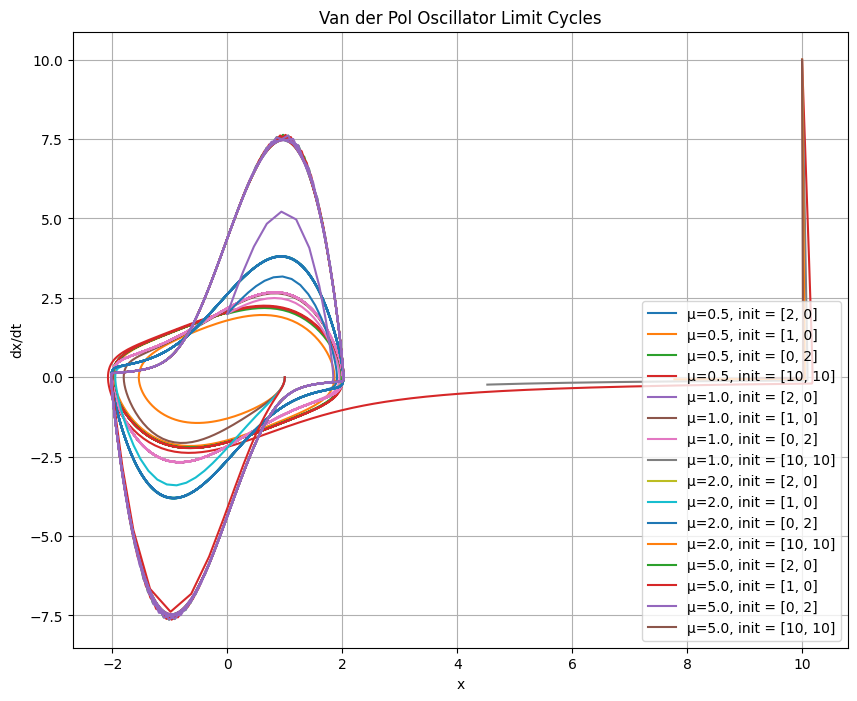

In [3]:

plt.figure(figsize=(10, 8))
for mu in mus:
  for init in initial_conditions:
    sol = solve_ivp(vanderpol, t_span, init, args=(mu,) , max_step=0.05)
    plt.plot(sol.y[0], sol.y[1], label=f'μ={mu}, init = {init}')

plt.title('Van der Pol Oscillator Limit Cycles')
plt.xlabel('x')
plt.ylabel('dx/dt')
plt.legend(loc = 'lower right')
plt.grid(True)
plt.show()

## Quiver Plot

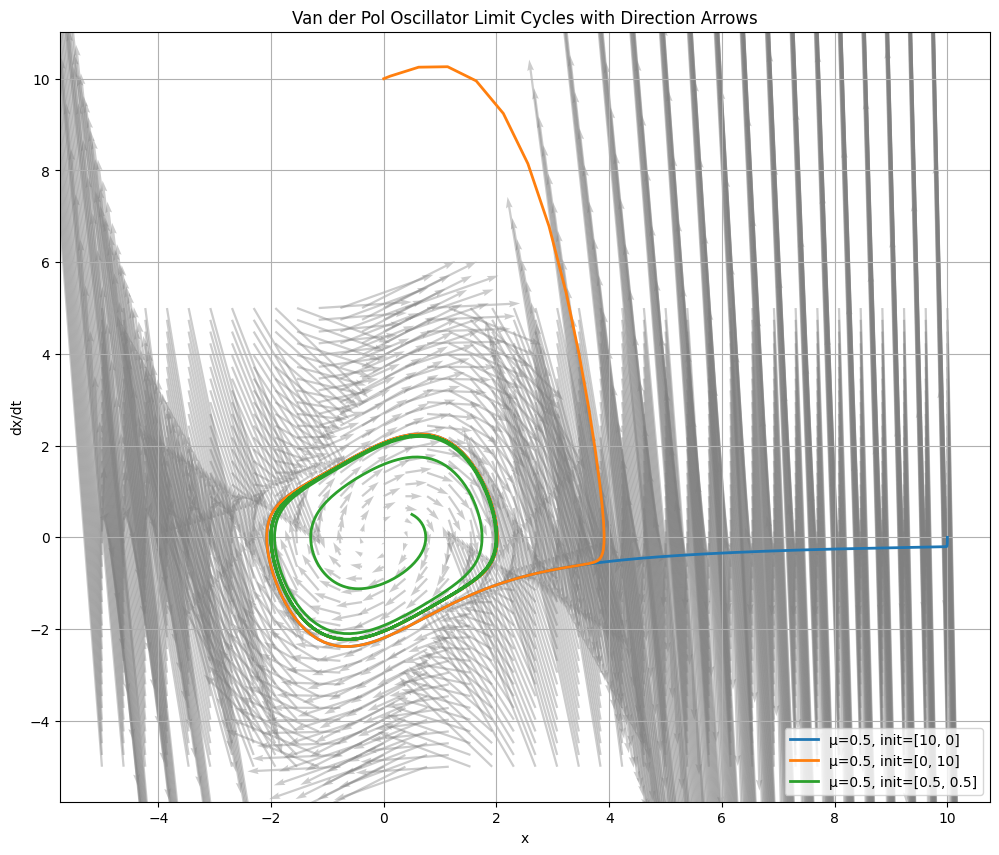

In [4]:
x_vals = np.linspace(-5, 10, 40)
dx_vals = np.linspace(-5, 5, 40)
X, DX = np.meshgrid(x_vals, dx_vals)

init_quiver = [[10, 0], [0,10], [0.5,0.5]]  # Initial condition
mu_quiver = [0.5]

# quiver plots 
# U = DX and V = mu * (1 - X**2) * DX - X
# These lines calculate the derivatives at each grid point:

# plt.quiver(X, DX, U, V, ...)
# This plots arrows at each grid point (X, DX) 
# direction of each arrow is determined by the vector [U, V]


plt.figure(figsize=(12, 10))
for mu in mu_quiver:
    # Compute vector field
    U = DX
    V = mu * (1 - X**2) * DX - X
    plt.quiver(X, DX, U, V, color='gray', alpha=0.4, scale= 50)
    # Plot trajectories
    for init in init_quiver:
        sol = solve_ivp(vanderpol, t_span, init, args=(mu_quiver), max_step=0.05)
        plt.plot(sol.y[0], sol.y[1], label=f'μ={mu}, init={init}', linewidth=2)

plt.title('Van der Pol Oscillator Limit Cycles with Direction Arrows')
plt.xlabel('x')
plt.ylabel('dx/dt')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Versus Time

In [5]:
U.shape, V.shape

((40, 40), (40, 40))

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
C:\Users\shiva\AppData\Local\Temp\ipykernel_4080\1809252614.py:24: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title(f'Van der Pol Oscillator State Variables vs Time $\mu$: {mu_2}')


Text(0, 0.5, 'dx/dt (velocity)')

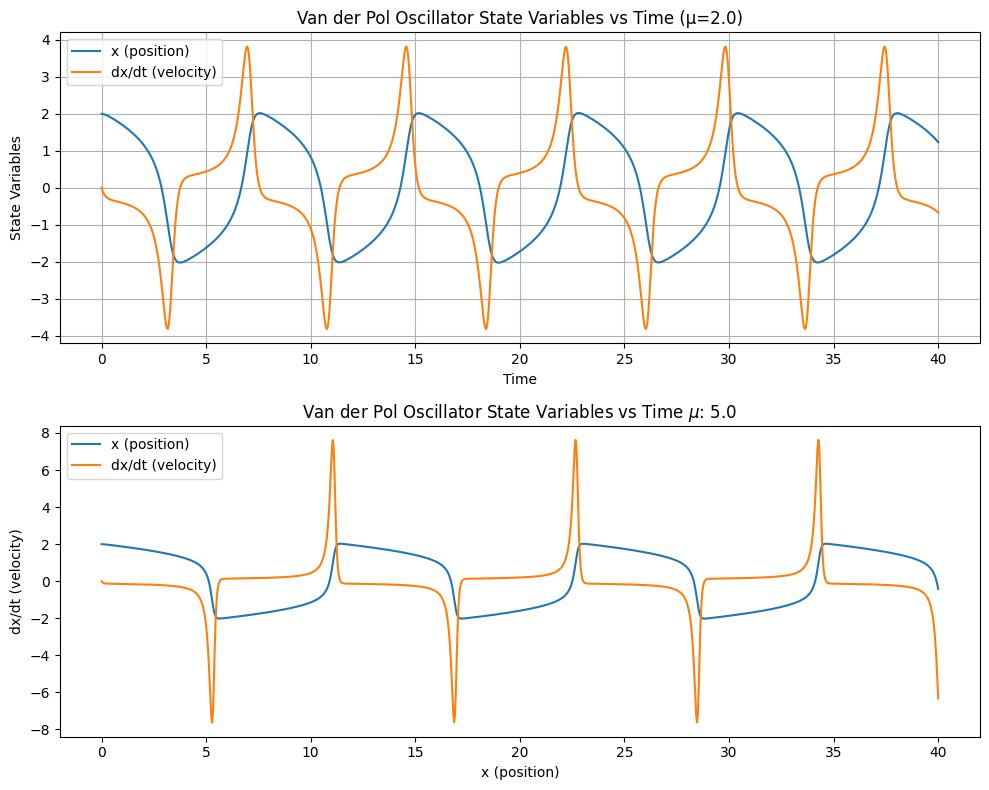

In [6]:
mu = 2.0  # Example value, you can change this
init = [2, 0]  # Example initial condition

mu_2 = 5.0
t_span = (0, 40)
t_eval = np.linspace(*t_span, 1000)  # Time points for smooth plot

sol = solve_ivp(vanderpol, t_span, init, args=(mu,), t_eval=t_eval)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), layout='tight' )
axes[0].plot(sol.t, sol.y[0], label='x (position)')
axes[0].plot(sol.t, sol.y[1], label='dx/dt (velocity)')
axes[0].set_title(f'Van der Pol Oscillator State Variables vs Time (μ={mu})')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('State Variables')
axes[0].legend()
axes[0].grid(True)

sol2 = solve_ivp(vanderpol, t_span, init, args=(mu_2,), t_eval=t_eval)

axes[1].plot(sol2.t, sol2.y[0], label='x (position)')
axes[1].plot(sol2.t, sol2.y[1], label='dx/dt (velocity)')
axes[1].legend()
axes[1].set_title(f'Van der Pol Oscillator State Variables vs Time $\mu$: {mu_2}')
axes[1].set_xlabel('x (position)')
axes[1].set_ylabel('dx/dt (velocity)')  


